In [83]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import torch
import torch.nn as nn   
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import copy

In [84]:
transform = transforms.Compose([
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
    
])

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=transform
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=transform
)

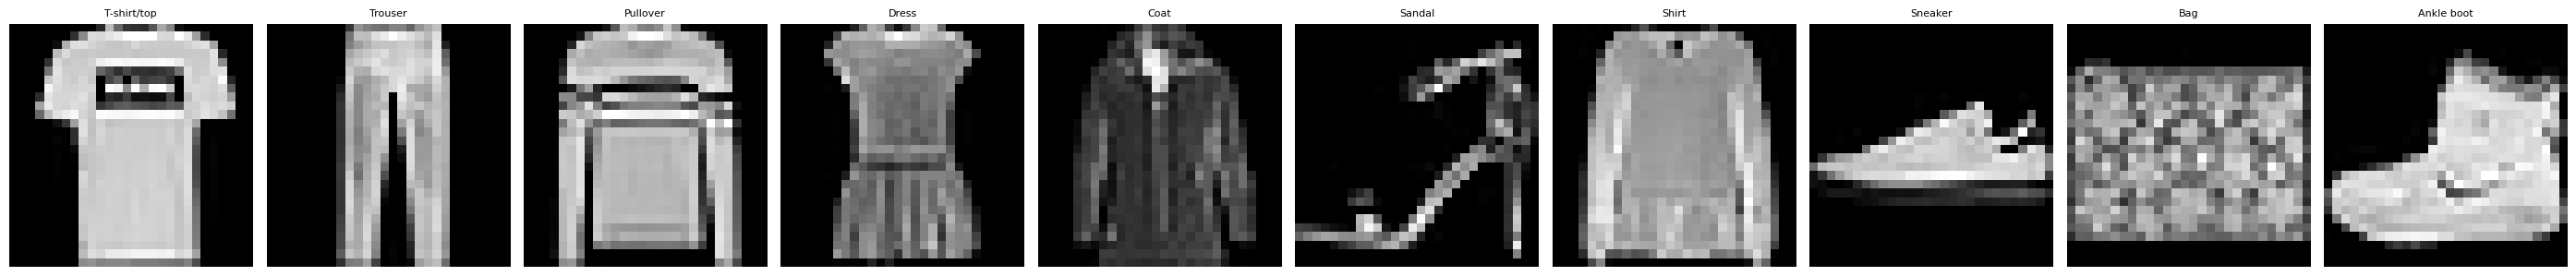

In [85]:
class_names = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

plt.figure(figsize=(28, 28))
num_labels = len(np.unique(y_train)
                 )
for label in range(num_labels):
    # find first image with this label
    idx = np.where(y_train == label)[0][0]

    plt.subplot(1, num_labels, label + 1)
    plt.imshow(x_train[idx], cmap="gray")
    plt.title(class_names[label], fontsize=8)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [86]:
batch_size = 64

train_data_loader = DataLoader(
    training_data,
    batch_size=batch_size,
    shuffle=True
)

test_data_loader = DataLoader(
    test_data,
    batch_size=batch_size,
    shuffle=False
)

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [91]:
class CNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv2d(in_channels=1, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)
        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.dropout = nn.Dropout(0.5)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.fc1 = nn.Linear(in_features=64 * 7 * 7, out_features=128)
        self.fc2 = nn.Linear(in_features=128, out_features=10)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1)

        x = F.relu(self.fc1(x))
        logits = self.fc2(x)

        return logits

In [92]:
model = CNN().to(device)
print(model)

CNN(
  (conv1): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout): Dropout(p=0.5, inplace=False)
  (pool): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (fc1): Linear(in_features=3136, out_features=128, bias=True)
  (fc2): Linear(in_features=128, out_features=10, bias=True)
)


In [93]:
loss_fn = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [94]:
images, labels = next(iter(train_data_loader))

images = images.to(device)
labels = labels.to(device)

outputs = model(images)
loss = loss_fn(outputs, labels)

print("Outputs shape:", outputs.shape)
print("Loss:", loss.item())

Outputs shape: torch.Size([64, 10])
Loss: 2.3066649436950684


In [95]:
epochs = 10
patience = 2
best_train_loss = float('inf')
epochs_no_improve = 0
best_model_wts = copy.deepcopy(model.state_dict())

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in train_data_loader:
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        prediction = model(images)
        loss = loss_fn(prediction, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item() * labels.size(0)
        _, predicted = prediction.max(1)
        correct += (predicted == labels).sum().item()
        total += labels.size(0)
        

    train_loss = running_loss / total
    train_accuracy = correct / total

    print(f"Epoch {epoch + 1}/{epochs}, Loss: {train_loss:.4f}, Accuracy: {train_accuracy:.4f}")

    if train_loss < best_train_loss:
        best_train_loss = train_loss
        best_model_wts = copy.deepcopy(model.state_dict())
        epochs_no_improve = 0
    else:
        epochs_no_improve += 1
        if epochs_no_improve >= patience:
            print("Early stopping triggered")
            break

model.load_state_dict(best_model_wts)

Epoch 1/10, Loss: 0.5032, Accuracy: 0.8188
Epoch 2/10, Loss: 0.3427, Accuracy: 0.8736
Epoch 3/10, Loss: 0.2985, Accuracy: 0.8907
Epoch 4/10, Loss: 0.2745, Accuracy: 0.8985
Epoch 5/10, Loss: 0.2493, Accuracy: 0.9070
Epoch 6/10, Loss: 0.2334, Accuracy: 0.9139
Epoch 7/10, Loss: 0.2207, Accuracy: 0.9189
Epoch 8/10, Loss: 0.2084, Accuracy: 0.9227
Epoch 9/10, Loss: 0.1987, Accuracy: 0.9262
Epoch 10/10, Loss: 0.1889, Accuracy: 0.9296


<All keys matched successfully>

In [96]:
model.eval()
val_loss = 0.0
val_correct = 0
val_total = 0

with torch.no_grad():
    for images, labels in test_data_loader:
        images, labels = images.to(device), labels.to(device)

        prediction = model(images)
        loss = loss_fn(prediction, labels)

        val_loss += loss.item() * labels.size(0)
        _, predicted = prediction.max(1)
        val_correct += (predicted == labels).sum().item()
        val_total += labels.size(0)

val_loss /= val_total
val_accuracy = val_correct / val_total

print(f"Validation Loss: {val_loss:.4f}, Validation Accuracy: {val_accuracy:.4f}")

Validation Loss: 0.2592, Validation Accuracy: 0.9101


In [97]:
torch.save(model.state_dict(), "fashion_mnist_cnn.pth")

In [98]:
from PIL import Image

model.eval()
model.load_state_dict(torch.load("fashion_mnist_cnn.pth"))
model.to(device)

image = Image.open("test_image_sneaker_mnist_fashion.png").convert("L")
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((28, 28)),
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])
image_tensor = transform(image).unsqueeze(0).to(device)

with torch.no_grad():
    prediction = model(image_tensor)
    _, predicted = prediction.max(1)
    predicted_class = class_names[predicted.item()]

print(f"Predicted item: {predicted.item()}")
print(f"Predicted class: {predicted_class}")

Predicted item: 7
Predicted class: Sneaker
